In [1]:
import datetime
from dateutil.relativedelta import relativedelta
import time
import json
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from castlib.cast import Cast
from castlib.reporter import Reporter
from castlib.prop import Prop
from castlib.event import Event

2020-12-15
9.93 months


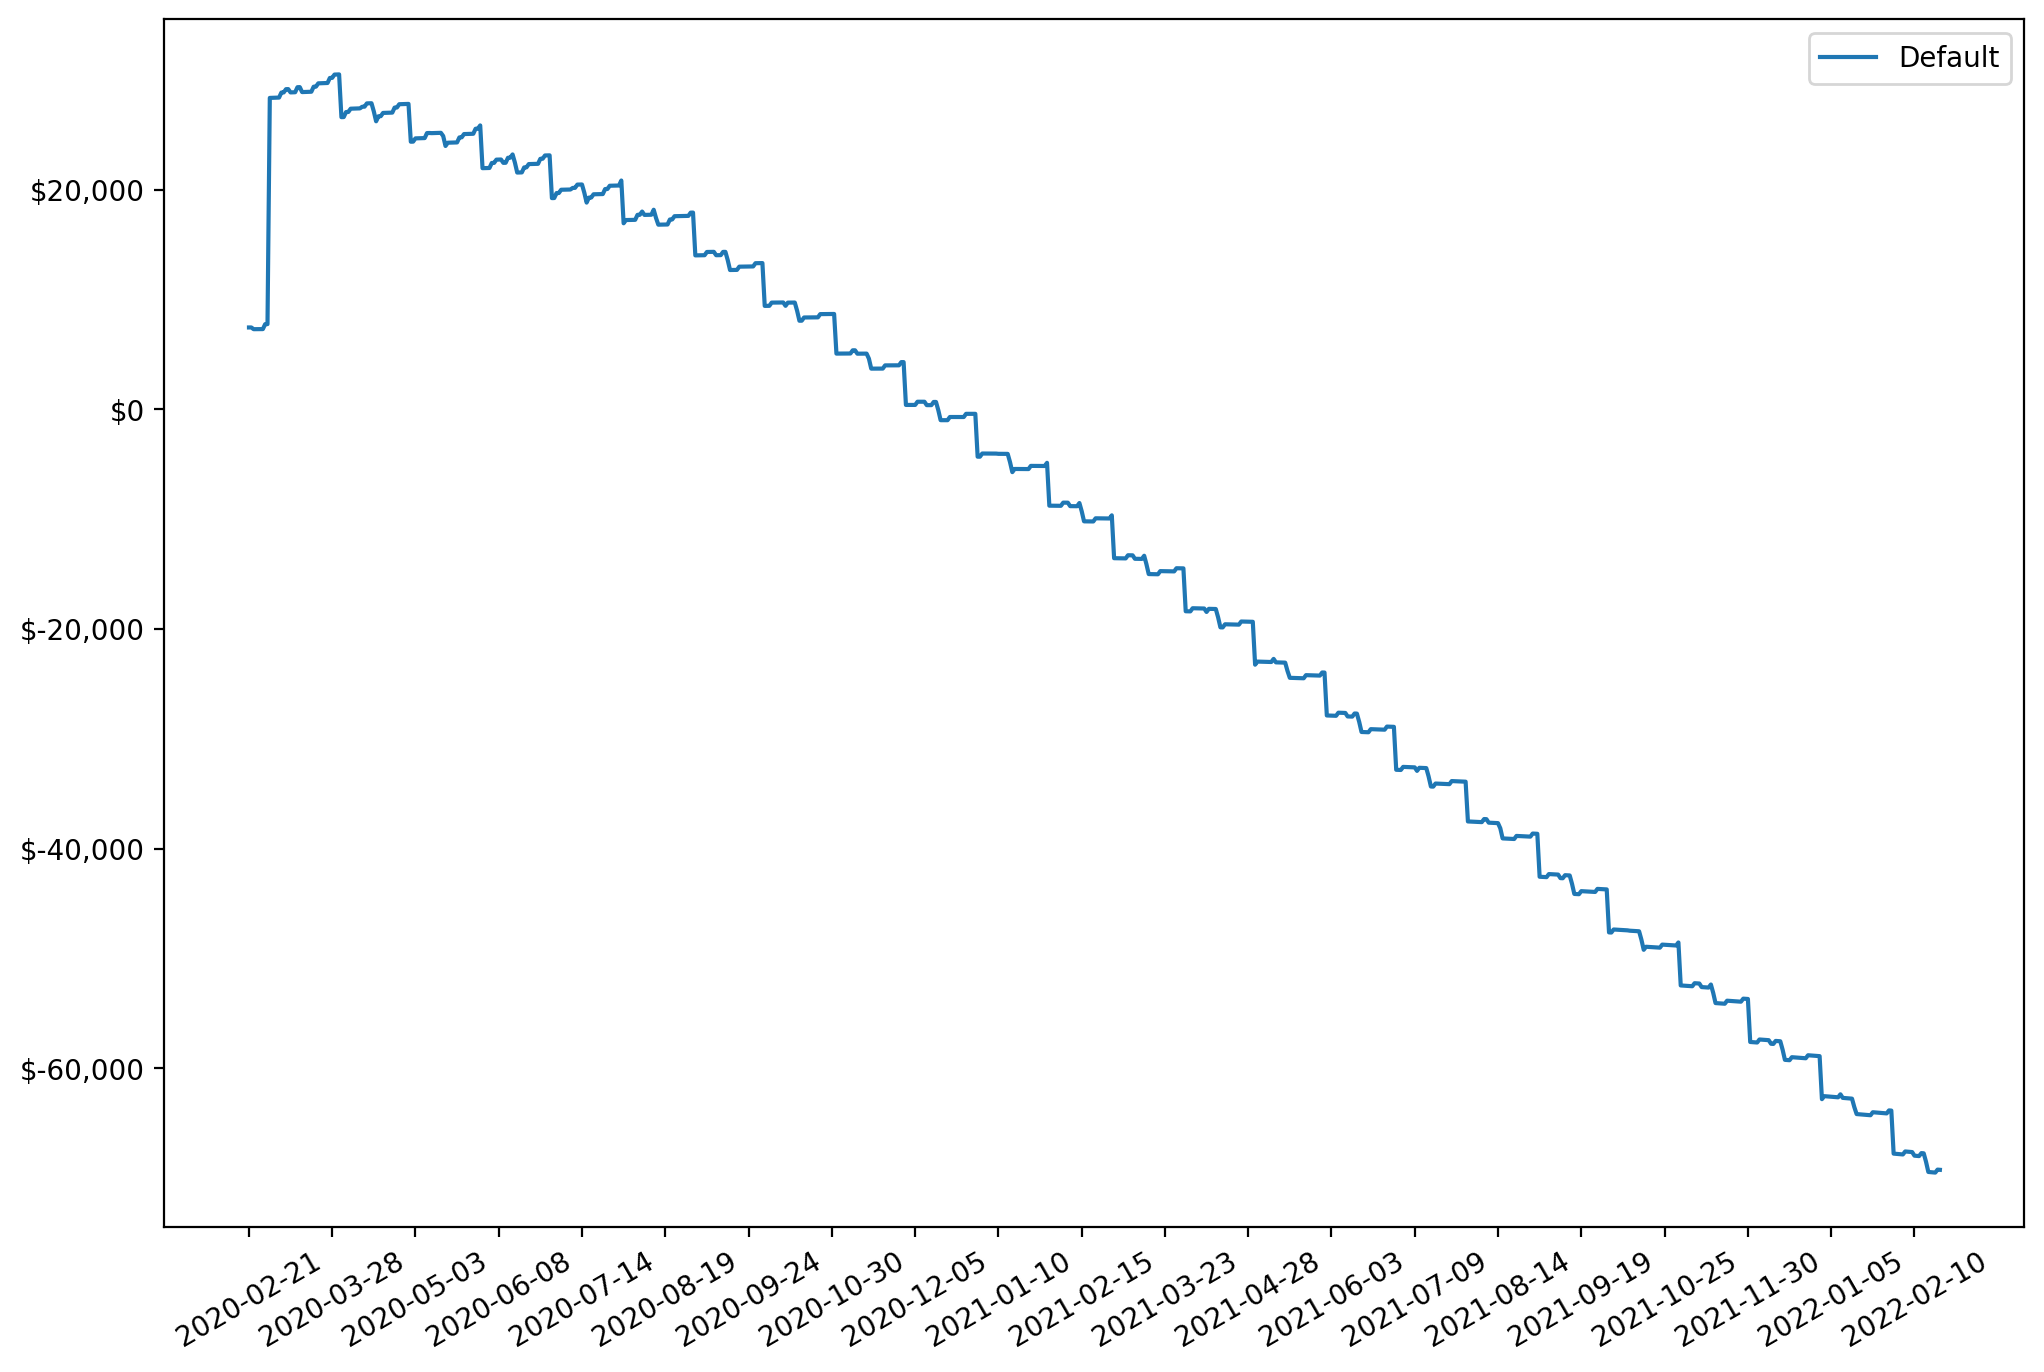

In [17]:
d = datetime.date

def AccountProp(name, amount):
        return Event(name=f"cashout {name}", amount=amount, date=d(2020, 3, 1))

month_of_severance = 10000
num_months = 1.5
severance = month_of_severance * num_months

# 401K
cashout_401k = False
Guideline = AccountProp("401k", 8000)

# Investments
Schwab = AccountProp("SchwabPortfolios", 7500)
Robinhood = AccountProp("Robinhood", 700)
Wealthfront = AccountProp("Wealthfront", 10000)

# Unemployment
unempoloyemnt_event = Event.today("Unemployment", 450)
unempoloyemnt_event.end = datetime.date.today() + relativedelta(weeks=26)
Unemployment = Prop(unempoloyemnt_event.weekly, name="Unemployment")

# Cash
personal_capital_cash = 7000

c = (Cast(balance=personal_capital_cash)
     .end_after(months=24)
     .report_with(Reporter)
     
     .add_event(Event(name="Severance", amount=severance, date=d(2020, 3, 1)))
     .add_event(Event(name="Last Check", amount=1800, date=d(2020, 2, 20)))
     .add_event(Event(name="Kennedy Flats", amount=1000, date=d(2020, 3, 1)))

     .add_event(Event(name="Rent", amount=-3900, date=d(2020, 2, 1)).monthly)
     .add_event(Event(name="Carmax", amount=-910, date=d(2020, 4, 16)).monthly)
     .add_event(Event(name="Progressive", amount=-310, date=d(2020, 2, 10)).monthly)
     .add_event(Event(name="Utilities", amount=-250, date=d(2020, 3, 15)).monthly)
     .add_event(Event(name="Sprint", amount=-400, date=d(2020, 3, 15)).monthly)
     .add_event(Event(name="Medical", amount=-100, date=d(2020, 3, 15)).monthly)

     .add_event(Event(name="Food", amount=-100, date=d(2020, 2, 2)).weekly)
     .add_event(Event(name="Gas", amount=-60, date=d(2020, 2, 2)).weekly)
     
     .add_event(Event(name="Unemployment", amount=450, date=d(2020, 3, 1)).weekly)
     
     .add_event([Schwab, Robinhood])
     
     .with_prop(Unemployment)

     .at_apr(10)
     .save("/Users/jacobsansbury/Casts/fired.json")
    )

months_til_broke = ((c.first_day_under(0) - d.today()).days / 30)

print(c.first_day_under(0))
print(f"{str(months_til_broke)[:4]} months")

c.report.running_balance();

In [19]:
fired = Cast.fromfile("/Users/jacobsansbury/Casts/fired.json")

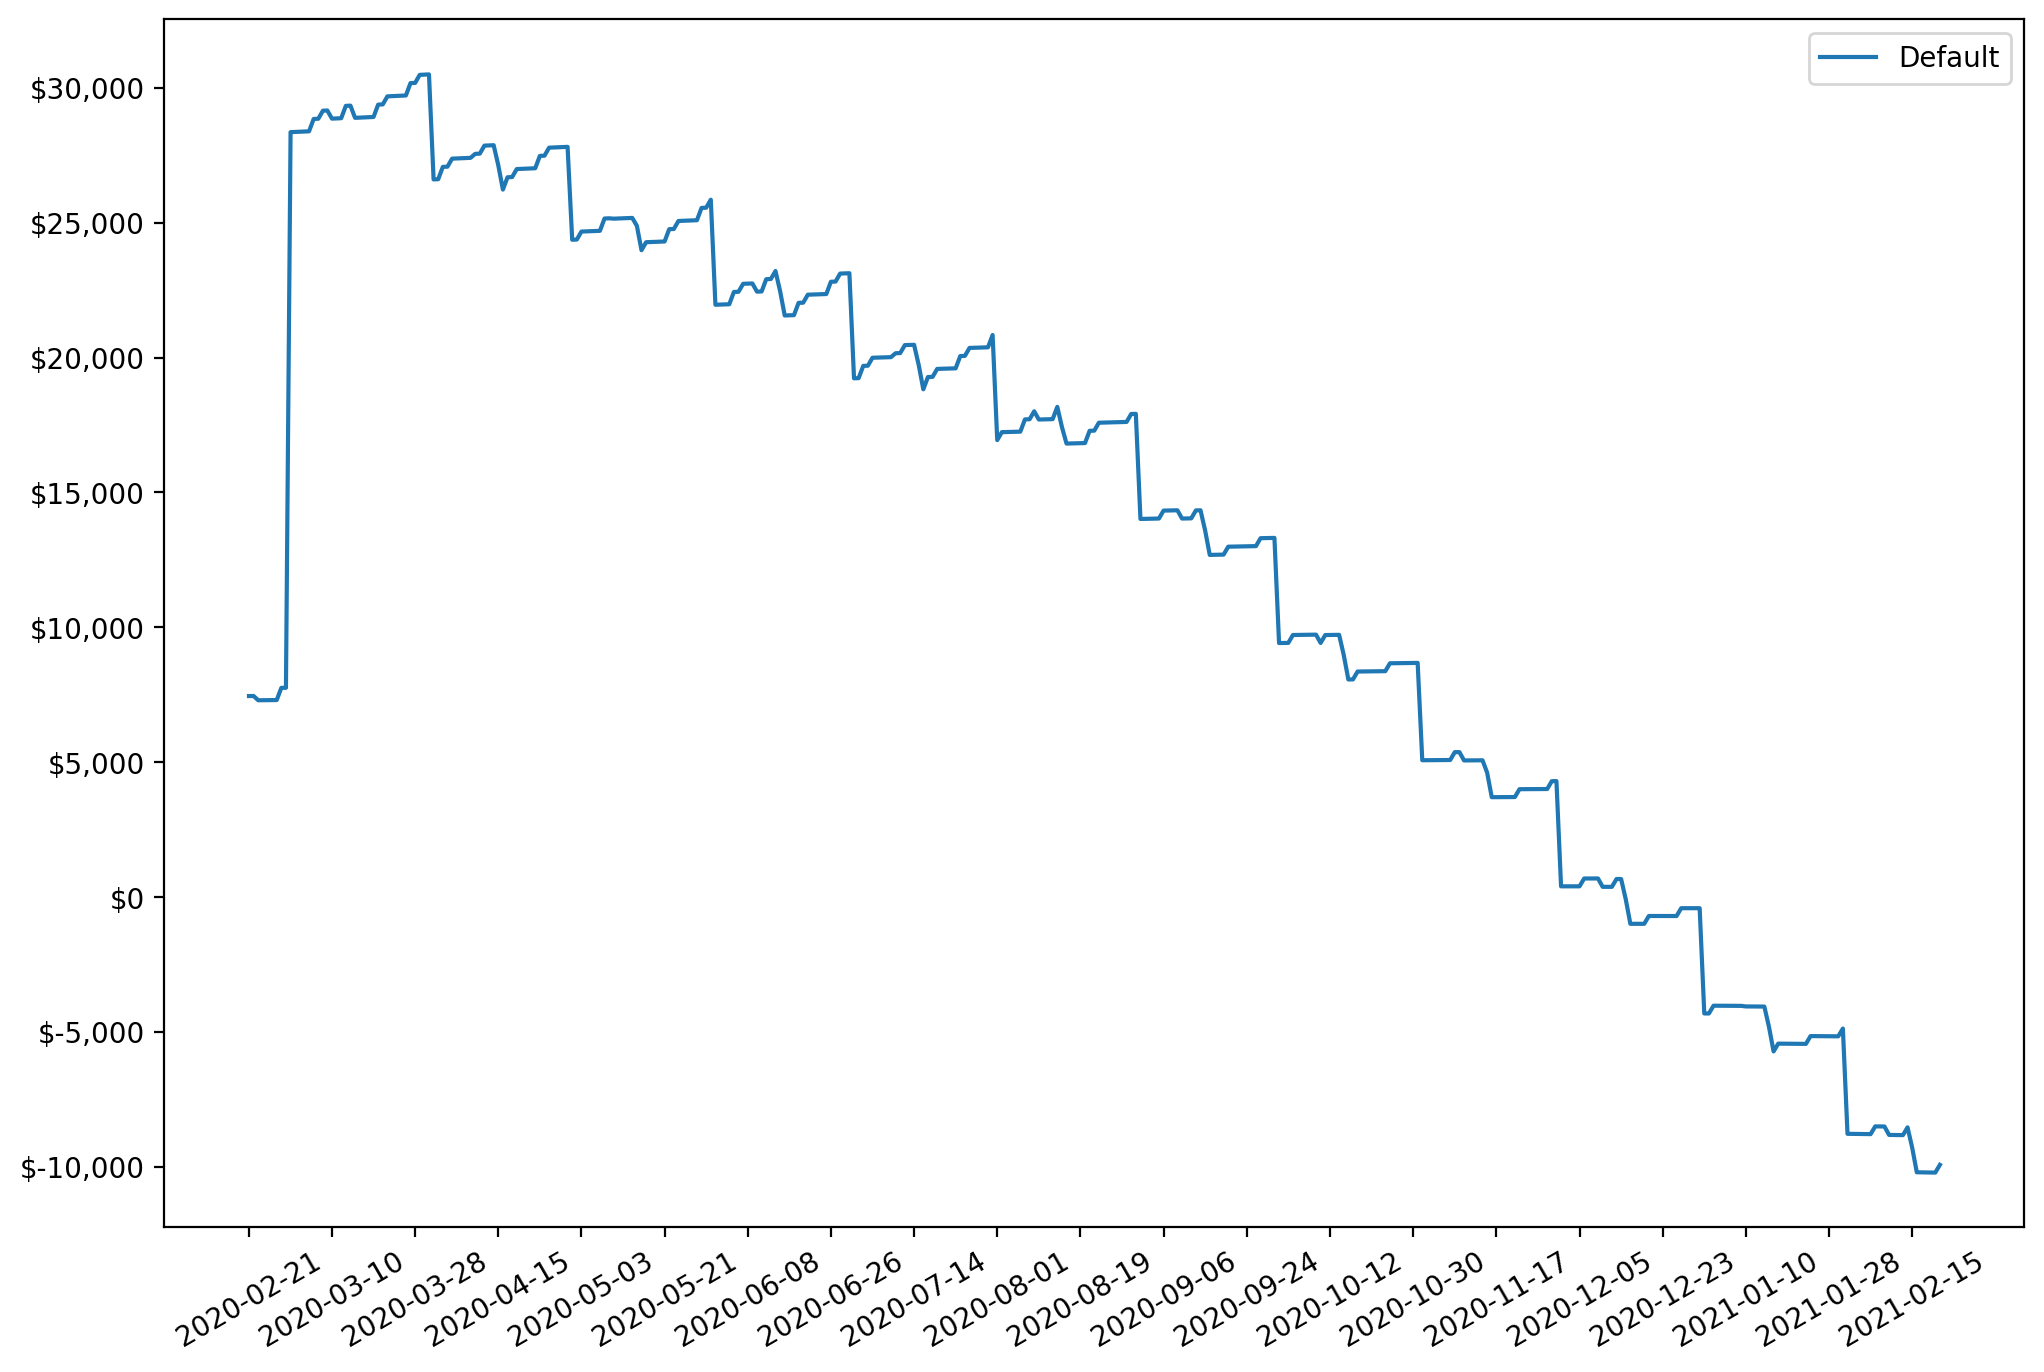

In [22]:
fired.report_with(Reporter).report.running_balance()